# Newsletter Agent: Research-Driven Article Generation with LangGraph

A multi-step **LangGraph** pipeline that takes a topic, researches it with **LLM-chosen tools**, writes a sourced article, and outputs clean **Markdown or HTML**.

This notebook is written as a reference: every section explains **what** the step does, **why** it exists, and **how** it works, so it can be reused to explain the project later.

---

## 1. What the project does

Input: a topic (for example, *"Latest developments in solid-state batteries"*) and an output format (`markdown` or `html`).
Output: a formatted newsletter article that is grounded in web and Wikipedia sources and ends with a Sources list.

## 2. Architecture

```
START
  |
  v
researcher_agent  <------------+
  |                            |
  |-- model asked for a tool --> tools   (runs web_search / wikipedia_lookup / get_current_date)
  |
  |-- model is done
  v
collect_research      (turns the tool conversation into one research string)
  |
  v
outliner              (research -> structured outline)
  |
  v
writer                (outline + research -> full article with Sources)
  |
  |-- output_format == "html"  --> html_formatter     --> END
  |-- otherwise                --> markdown_formatter --> END
```

## 3. LangGraph concepts demonstrated

| Concept | Where it appears |
|---|---|
| Typed shared **State** | `NewsletterState` |
| **Reducers** (`add_messages`) | the `messages` field |
| **Nodes** as plain Python functions returning partial updates | every node |
| **Tool calling** (model chooses tools) | `researcher_agent` + `ToolNode` |
| **Cycles / loops** | `researcher_agent` <-> `tools` |
| **Conditional edges** | the tool loop and the format fork |
| **Loop safety limits** | tool budget + `recursion_limit` |
| Nodes that do **not** call an LLM | `collect_research_node` |

## 4. Tech stack

Python, LangGraph, LangChain, OpenAI `gpt-4o-mini`, DuckDuckGo search (`ddgs`), Wikipedia API.

## 5. How this project evolved

1. **v1:** a linear pipeline `outliner -> writer -> formatter`. The model wrote from memory, with no sources.
2. **v2:** added a fixed `researcher` node that always ran two web searches. Articles became current and cited.
3. **v3:** replaced the fixed searches with a **tool-calling agent** that decides what to look up and when to stop.
4. **v4:** split the formatter into two nodes and routed between them with a **conditional edge**.

This notebook contains the final version (v4).

---
# Step 1: Install libraries and load the API key

**What it does:** installs the packages and loads the OpenAI key from Colab Secrets.

**Why these packages:**

| Package | Purpose |
|---|---|
| `langgraph` | the graph framework: state, nodes, edges, loops |
| `langchain`, `langchain-openai` | message classes, tool decorator, and the OpenAI chat model wrapper |
| `ddgs` | DuckDuckGo search from Python, with no API key needed |
| `requests` | calls the Wikipedia API |

**Why Colab Secrets:** the key is never typed into a cell, so it cannot leak when the notebook is shared or pushed to Git.

**Setup:** in Colab, click the key icon in the left sidebar, add a secret named `OPENAI_API_KEY`, and enable *Notebook access*. The OpenAI API needs billing credits, separate from a ChatGPT subscription.

In [1]:
!pip install -q -U langgraph langchain langchain-openai ddgs requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.0/256.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.4/162.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 32.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("API key loaded:", "OPENAI_API_KEY" in os.environ)

API key loaded: True


---
# Step 2: Create the language models

**What it does:** creates two chat model objects that the nodes will share.

**Why two models:** the same model with different `temperature` settings serves two different jobs.

| Object | Temperature | Used by | Why |
|---|---|---|---|
| `llm` | 0.7 | outliner, writer, formatters | writing benefits from some creativity |
| `agent_llm` | 0 | the research agent | tool choices should be consistent and repeatable |

**`gpt-4o-mini`** is cheap and fast, which suits a learning project. Any OpenAI chat model your account can access works here.

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)        # for writing
agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)    # for deciding which tool to call

print(llm.invoke("Say hello in one short sentence.").content)

Hello!


---
# Step 3: Define the shared State

**What it does:** defines `NewsletterState`, the single shared "clipboard" that every node reads from and writes to.

**Why it matters:** in LangGraph, nodes never call each other directly. They communicate only through State. Each node returns a **partial update** (only the keys it changed), and LangGraph merges it into the State before running the next node.

| Field | Written by | Read by |
|---|---|---|
| `topic`, `output_format` | the caller (input) | researcher, outliner, writer, router |
| `messages` | researcher agent and tools | researcher agent, collector |
| `research` | `collect_research` | outliner, writer |
| `outline` | outliner | writer |
| `article` | writer | formatters |
| `final_output` | a formatter | the caller |

### Reducers: overwrite vs append

By default a returned value **overwrites** the old one. That is right for fields written once (`outline`, `article`).

The research loop is different. The agent node runs several times, and the tool node also adds to the conversation. If each write replaced the previous one, the model would forget what it had already searched.

`Annotated[list[AnyMessage], add_messages]` attaches a **reducer** to `messages`. LangGraph calls the reducer as `new_value = reducer(old_value, update)` each time a node writes that field, so messages accumulate instead of being replaced.

In [4]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class NewsletterState(TypedDict):
    topic: str                                             # input: the topic
    output_format: str                                     # input: "markdown" or "html"
    messages: Annotated[list[AnyMessage], add_messages]    # research conversation (APPENDS)
    research: str                                          # written by collect_research
    outline: str                                           # written by outliner
    article: str                                           # written by writer
    final_output: str                                      # written by a formatter

### Demo: why the reducer matters

This small graph has no LLM. Two nodes each add one message. The first state field has no reducer, so the last write wins. The second uses `add_messages`, so the history accumulates. Keep this cell as a quick way to show the difference.

In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage

class OverwriteState(TypedDict):
    messages: list                                   # no reducer -> overwrite

class AppendState(TypedDict):
    messages: Annotated[list, add_messages]          # reducer -> append

def node_a(state): return {"messages": [AIMessage(content="from node A")]}
def node_b(state): return {"messages": [AIMessage(content="from node B")]}

def run_demo(state_class):
    b = StateGraph(state_class)
    b.add_node("a", node_a)
    b.add_node("b", node_b)
    b.add_edge(START, "a")
    b.add_edge("a", "b")
    b.add_edge("b", END)
    out = b.compile().invoke({"messages": [HumanMessage(content="start")]})
    return [m.content for m in out["messages"]]

print("Overwrite:", run_demo(OverwriteState))   # only the last node's message survives
print("Append:   ", run_demo(AppendState))      # full history is kept

Overwrite: ['from node B']
Append:    ['start', 'from node A', 'from node B']


---
# Step 4: Build the tools

**What it does:** creates three tools the research agent can choose from.

**Why three distinct tools:** the goal is to let the **model** decide what to use. That only works when the tools have clearly different jobs.

| Tool | Best for |
|---|---|
| `web_search` | recent news, current developments, statistics |
| `wikipedia_lookup` | stable background, definitions, history |
| `get_current_date` | knowing what "recent" means today |

### How a model "chooses" a tool

The model never sees your function code. It sees only each tool's **name, docstring, and argument types**. The docstring is the main steering signal, so phrases like `RECENT or CURRENT` and `STABLE BACKGROUND` are written on purpose. A vague docstring such as "Look things up" gives the model nothing to base a choice on.

The model also never *runs* a tool. It returns a structured request (`tool_calls`), and our code executes it.

### Helper: `search_web`

Wraps DuckDuckGo and formats results as text (title, URL, summary). It keeps URLs so the writer can cite them. Free search endpoints sometimes rate-limit or return nothing, so it **retries** and, if it still fails, **returns an error string instead of raising**. That lets the pipeline continue rather than crash.

### Why `get_current_date` exists

During development the agent searched for "latest developments ... 2023" because the model assumed the current year from its training data. Every source it found was three years old. A date tool plus a prompt rule (call it first) fixed this. It is the clearest example in the project of why tool descriptions and prompts are part of the logic.

*Note:* `datetime.now()` returns the Colab server's clock, which is UTC, so near midnight it can differ from your local date.

In [6]:
import time
import requests
from datetime import datetime
from ddgs import DDGS
from langchain_core.tools import tool


def search_web(query: str, max_results: int = 5, retries: int = 2) -> str:
    """Search DuckDuckGo and return results as one formatted text block."""
    results, last_error = None, None
    for attempt in range(retries + 1):
        try:
            results = DDGS().text(query, max_results=max_results)
            if results:
                break
        except Exception as e:
            last_error = e
        time.sleep(1.5)                     # brief pause before retrying

    if not results:
        return f"(Search failed: {last_error or 'no results found'})"

    blocks = []
    for i, r in enumerate(results, 1):
        blocks.append(
            f"[{i}] {r['title']}\n"
            f"Source: {r['href']}\n"
            f"Summary: {r['body']}"
        )
    return "\n\n".join(blocks)


@tool
def web_search(query: str) -> str:
    """Search the web for RECENT or CURRENT information: news, new product
    launches, latest developments, statistics, anything from the past few
    years. Use a specific, focused query. Returns titles, URLs and summaries."""
    print(f"    [tool] web_search: {query}")
    return search_web(query, max_results=4)


@tool
def wikipedia_lookup(topic: str) -> str:
    """Look up STABLE BACKGROUND knowledge on Wikipedia: definitions, history,
    how something works, biographies, established concepts. Pass a short
    topic name such as 'Lithium-ion battery', not a full sentence.
    Not suitable for recent news."""
    print(f"    [tool] wikipedia_lookup: {topic}")
    headers = {"User-Agent": "NewsletterBot/1.0 (learning project)"}
    api = "https://en.wikipedia.org/w/api.php"
    try:
        search = requests.get(api, params={
            "action": "query", "list": "search", "srsearch": topic,
            "srlimit": 1, "format": "json",
        }, headers=headers, timeout=10).json()
        hits = search["query"]["search"]
        if not hits:
            return "(No Wikipedia article found.)"

        title = hits[0]["title"]
        page = requests.get(api, params={
            "action": "query", "prop": "extracts", "exintro": 1,
            "explaintext": 1, "titles": title, "redirects": 1, "format": "json",
        }, headers=headers, timeout=10).json()
        extract = next(iter(page["query"]["pages"].values())).get("extract", "")
        url = "https://en.wikipedia.org/wiki/" + title.replace(" ", "_")
        return f"Title: {title}\nSource: {url}\n\n{extract[:2000]}"
    except Exception as e:
        return f"(Wikipedia lookup failed: {e})"


@tool
def get_current_date() -> str:
    """Get today's date. Use this ONLY when you need to know the current
    date, month or year, for example to decide what counts as 'recent'."""
    print("    [tool] get_current_date")
    return datetime.now().strftime("%A, %B %d, %Y")


tools = [web_search, wikipedia_lookup, get_current_date]
print("Tools registered:", [t.name for t in tools])

Tools registered: ['web_search', 'wikipedia_lookup', 'get_current_date']


### Test each tool on its own

Always test tools in isolation before giving them to a model. It separates "the tool is broken" from "the model chose badly".

In [7]:
print(get_current_date.invoke({}))
print("-" * 40)
print(wikipedia_lookup.invoke({"topic": "Solid-state battery"})[:400])
print("-" * 40)
print(web_search.invoke({"query": "solid-state battery news"})[:400])

    [tool] get_current_date
Wednesday, October 07, 2026
----------------------------------------
    [tool] wikipedia_lookup: Solid-state battery
Title: Solid-state battery
Source: https://en.wikipedia.org/wiki/Solid-state_battery

A solid-state battery (SSB) is an electrical battery that uses a solid electrolyte to conduct ions between the electrodes, instead of the liquid or gel polymer electrolytes found in conventional batteries. Theoretically, solid-state batteries offer much higher energy density than the typical lithium-ion or lithiu
----------------------------------------
    [tool] web_search: solid-state battery news
[1] All Current And Upcoming EVs With Solid-State Batteries
Source: https://insideevs.com/news/771402/every-solid-state-battery-ev/
Summary: Update: This list has been updated with the latest solid-state battery developments at Karma Automotive and Donut Lab. Talk to any battery executive, and they'll tell you lithium-ion batteries ...

[2] The biggest problem w

### Watch the model choose between tools

`bind_tools` tells the model which tools exist. We then ask five questions and print which tool each one triggers. A good result is: background question -> Wikipedia, news question -> web search, date question -> date tool, greeting -> no tool, mixed question -> two tools.

Tool choice is probabilistic. Treat this table as a **spot check**, not a guarantee.

In [8]:
llm_with_tools = agent_llm.bind_tools(tools)

test_questions = [
    ("Who invented the lithium-ion battery and how does it work?", "wikipedia_lookup"),
    ("What battery technology news came out recently?",            "web_search"),
    ("What is today's date?",                                      "get_current_date"),
    ("Say hello in one short sentence.",                           "(none)"),
    ("Give me the background on solid-state batteries AND the latest industry news.",
                                                                   "wikipedia + web_search"),
]

print(f"{'Question':<75}{'Expected':<26}{'Model chose'}")
print("-" * 130)
for question, expected in test_questions:
    resp = llm_with_tools.invoke(question)
    chosen = [f"{c['name']}({list(c['args'].values())[0] if c['args'] else ''})"
              for c in resp.tool_calls] or ["(none)"]
    print(f"{question[:73]:<75}{expected:<26}{', '.join(chosen)}")

Question                                                                   Expected                  Model chose
----------------------------------------------------------------------------------------------------------------------------------
Who invented the lithium-ion battery and how does it work?                 wikipedia_lookup          wikipedia_lookup(Lithium-ion battery), web_search(who invented the lithium-ion battery)
What battery technology news came out recently?                            web_search                web_search(recent battery technology news 2023)
What is today's date?                                                      get_current_date          get_current_date()
Say hello in one short sentence.                                           (none)                    (none)
Give me the background on solid-state batteries AND the latest industry n  wikipedia + web_search    wikipedia_lookup(Solid-state battery), web_search(latest news on solid-state batteries 20

---
# Step 5: The research agent (decide, act, repeat)

This is the core of the project. It is built from three small pieces.

### 5a. The agent node: *decides*, never acts

`researcher_agent_node` sends the conversation so far to the tool-bound model and appends the reply to `messages`. The reply is one of two things:

| Model reply | Meaning |
|---|---|
| an `AIMessage` with `tool_calls` | "I need more information" |
| plain text with no `tool_calls` | "I'm done, here are my research notes" |

The node does **not** run tools. Splitting *decide* from *act* is what makes a loop possible.

**System prompt, added at call time:** it is prepended on each call but not stored in State, so it never piles up in `messages`. It tells the model which tool fits which need, to call `get_current_date` first for anything recent, and to finish with bulleted notes that include source URLs.

### 5b. A hard tool budget

The prompt asks for at most 4 tool calls, but a prompt is only a request. In code, the node counts the `ToolMessage`s already in `messages`. Once the count reaches `MAX_TOOL_CALLS`, it calls the model **without tools bound** and tells it to write its notes. The model cannot ask for another tool, so the loop is guaranteed to end, and the pipeline still gets usable research.

*Known behavior:* the model can request several tools in one turn, so the final count can exceed the limit (for example 5 results with a limit of 2). The check happens **before** each agent turn, so this is a budget on turns, not a strict cap. That is acceptable here; a strict cap would require trimming `tool_calls` in code.

### 5c. `ToolNode` and the router

- `ToolNode(tools)` is a prebuilt LangGraph node. It reads the last `AIMessage`, runs each requested tool by name (in parallel if several), and appends the results as `ToolMessage`s.
- `route_after_agent` is a **router function**: it only *reads* State and returns a label, `"tools"` or `"done"`. Routers never modify State.

Together they form the loop: **agent -> tools -> agent -> ... -> done**.

In [9]:
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.prebuilt import ToolNode

MAX_TOOL_CALLS = 4   # the node reads this at call time, so you can change it any time


def build_research_prompt() -> str:
    return (
        "You are a research assistant preparing background notes for a newsletter "
        "writer. You have three tools:\n"
        "- web_search: recent news, current developments, statistics\n"
        "- wikipedia_lookup: stable background, definitions, history\n"
        "- get_current_date: today's date\n\n"
        "Process:\n"
        "1. If the topic involves anything recent ('latest', 'new', 'current', "
        "trends, news), call get_current_date FIRST, before any web_search. "
        "Never assume the current year. Use the year it returns in your queries.\n"
        "2. Use only the tools that fit; skip tools that add nothing.\n"
        f"3. Make at most {MAX_TOOL_CALLS} tool calls in total. Do not repeat a "
        "search you have already made.\n"
        "4. When you have enough, STOP calling tools and reply with research notes: "
        "a bulleted list of key facts, each followed by its source URL in "
        "parentheses. Only include facts that appear in the tool results. "
        "Mention the date of each source when the results show it.\n"
    )


def make_task(topic: str) -> HumanMessage:
    """The first message in the research conversation: what to research."""
    return HumanMessage(content=f"Research this newsletter topic: {topic}")


def researcher_agent_node(state: NewsletterState) -> dict:
    """Asks the model what to do next (call a tool or finish), with a hard tool budget."""
    used = sum(1 for m in state["messages"] if isinstance(m, ToolMessage))
    messages = [SystemMessage(content=build_research_prompt())] + state["messages"]

    if used >= MAX_TOOL_CALLS:
        print(f"--- Researcher agent: budget reached ({used}/{MAX_TOOL_CALLS}), forcing final notes ---")
        messages.append(SystemMessage(content=(
            "Your tool budget is used up. Do NOT request any tools. Write the "
            "research notes now, using only the tool results above."
        )))
        response = agent_llm.invoke(messages)            # no tools bound -> cannot loop
    else:
        print(f"--- Researcher agent thinking (tool calls used: {used}/{MAX_TOOL_CALLS}) ---")
        response = llm_with_tools.invoke(messages)
        for c in response.tool_calls:
            print(f"    decision: call {c['name']}({c['args']})")
        if not response.tool_calls:
            print("    decision: finished researching")

    return {"messages": [response]}            # only the NEW message; the reducer appends it


tool_node = ToolNode(tools)


def route_after_agent(state: NewsletterState) -> str:
    """Router: read the agent's last message and pick the next step."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"      # the model asked for tools -> run them
    return "done"           # plain-text answer -> research is finished

---
# Step 6: Collect the research

**What it does:** `collect_research_node` converts the agent's message trail into a single `research` string for the writing nodes.

**Why a separate node:** after the loop, `messages` holds a long mix of Human, AI, and Tool messages. The outliner and writer should not have to deal with tool-call metadata. One bridge node keeps the two halves of the pipeline independent. You could swap the agent loop for a different research method and nothing downstream would change.

**What the research string contains:**
1. `Date of research:` taken from the date tool, so the writer knows what "recent" means.
2. `Research notes:` the agent's own summary (its final plain-text message).
3. `Raw source material:` the original search and Wikipedia text.

**Why include raw material as well as the summary:** summaries can drop or distort details. Giving the writer the originals lets it check claims, and the writer prompt says to prefer the raw text if the two disagree.

This node makes **no LLM call**. It only reshapes data, which shows that a LangGraph node can be any function that takes State and returns an update.

In [10]:
def collect_research_node(state: NewsletterState) -> dict:
    """Turns the researcher's message trail into one research string."""
    print("--- Collect research node running ---")
    messages = state["messages"]

    # 1. The agent's final notes: the last AIMessage with text and no tool calls
    notes = ""
    for m in reversed(messages):
        if isinstance(m, AIMessage) and not m.tool_calls and m.content:
            notes = m.content
            break

    # 2. The raw evidence: every ToolMessage except the date lookup
    evidence = [
        f"[{m.name}]\n{m.content}"
        for m in messages
        if isinstance(m, ToolMessage) and m.name != "get_current_date"
    ]

    # 3. Today's date, if the agent looked it up
    date_lines = [m.content for m in messages
                  if isinstance(m, ToolMessage) and m.name == "get_current_date"]
    date_line = f"Date of research: {date_lines[0]}\n\n" if date_lines else ""

    if not notes:
        notes = "(The researcher produced no notes.)"

    research_text = (
        f"{date_line}"
        f"## Research notes\n{notes}\n\n"
        f"## Raw source material\n" + "\n\n---\n\n".join(evidence)
    )
    return {"research": research_text}

---
# Step 7: The Outliner and Writer nodes

Both are ordinary nodes: read State, call the LLM, return one field.

### Outliner
- **Reads:** `topic`, `research`. **Writes:** `outline`.
- Produces a title, an intro point, 3-5 sections with 2-3 bullets each, and a conclusion point.
- **Why outline first:** planning structure before writing prose gives more coherent articles than a single "write an article" call, and each stage can be inspected on its own.

### Writer
- **Reads:** `topic`, `outline`, `research`. **Writes:** `article`.
- **Grounding rules in the prompt:** take facts and figures *only* from the research, prefer raw material over the summary, leave out unsupported claims instead of inventing statistics, do not present old sources as recent news, and end with a Sources list of URLs.
- **Why the rules matter:** without them the model blends search results with its memory and may state outdated or invented numbers. Grounding is the main quality gain of adding research.

### Message roles
`SystemMessage` sets the model's role and rules; `HumanMessage` carries the input data. Keeping them separate gives more consistent behavior than one large string.

In [11]:
def outliner_node(state: NewsletterState) -> dict:
    """Takes the topic and research and produces a structured outline."""
    print("--- Outliner node running ---")
    messages = [
        SystemMessage(content=(
            "You are an expert newsletter editor. Given a topic and research "
            "notes, create a clear, well-structured outline for a short "
            "newsletter article. Include: a catchy title, a short intro point, "
            "3-5 main sections with 2-3 bullet points each, and a conclusion "
            "point. Base the sections on the most relevant and current facts "
            "in the research. Return only the outline, with no extra commentary."
        )),
        HumanMessage(content=(
            f"Topic: {state['topic']}\n\n"
            f"Research:\n{state['research']}"
        )),
    ]
    return {"outline": llm.invoke(messages).content}


def writer_node(state: NewsletterState) -> dict:
    """Takes the topic, research and outline and writes the full article."""
    print("--- Writer node running ---")
    messages = [
        SystemMessage(content=(
            "You are a skilled newsletter writer. Write an engaging, "
            "easy-to-read article that follows the outline you are given. "
            "Use a friendly, professional tone. Keep each section concise "
            "(1-2 short paragraphs). Keep the outline's title and section "
            "headings.\n\n"
            "Rules for facts: the research has two parts, 'Research notes' "
            "(a summary) and 'Raw source material' (the original text). Take "
            "facts and figures ONLY from the research, and prefer the raw "
            "material when the two differ. If the research does not support a "
            "claim, leave it out or phrase it in general terms. Do not invent "
            "statistics. If a source is old, do not present it as recent news. "
            "End with a short 'Sources' section listing the URLs you relied "
            "on.\n\nReturn only the article text."
        )),
        HumanMessage(content=(
            f"Topic: {state['topic']}\n\n"
            f"Outline:\n{state['outline']}\n\n"
            f"Research:\n{state['research']}"
        )),
    ]
    return {"article": llm.invoke(messages).content}

---
# Step 8: Two formatter nodes and a format router

### Why split one formatter into two
An earlier version had one formatter with an `if` inside. Splitting it gives:

| One node with `if` | Two nodes + a router |
|---|---|
| the branching is hidden inside a function | the branching is **visible in the graph diagram** |
| adding a format means editing a growing function | adding a format means adding a node and one routing label |
| one prompt must serve every format | each format has its own tuned prompt |

Both nodes read `article` and write `final_output`. Only one runs per invocation, so the default overwrite behavior is fine and no reducer is needed.

### `strip_code_fences`
Models sometimes wrap output in triple backticks even when told not to. That would show up as junk in a saved `.html` or `.md` file, so this helper removes the fences defensively.

### The router
`route_by_format` reads `output_format` and returns `"html"` or `"markdown"`. Anything unrecognized (including a typo like `"markdwon"`) falls back to Markdown so the pipeline does not crash. If you prefer to fail loudly, raise a `ValueError` for unknown formats instead; the trade-off is strictness versus forgiveness.

### Prompt details
Both prompts say *do not change the wording*, so a formatter stays a formatter and does not quietly rewrite the article. The HTML prompt states that the input is Markdown and the output must be HTML, and it requires `<a href>` links for sources.

In [12]:
def strip_code_fences(text: str) -> str:
    """Remove ```markdown / ```html fences if the model added them."""
    text = text.strip()
    if text.startswith("```"):
        lines = text.split("\n")[1:]                 # drop the opening fence line
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]                       # drop the closing fence line
        text = "\n".join(lines).strip()
    return text


def markdown_formatter_node(state: NewsletterState) -> dict:
    """Formats the article as clean Markdown."""
    print("--- Markdown formatter running ---")
    response = llm.invoke([
        SystemMessage(content=(
            "You are a formatting assistant. Clean up the given article into "
            "well-structured Markdown: one # title, ## section headings, "
            "consistent spacing, and bullet lists where appropriate. Keep the "
            "Sources section as a list of Markdown links. Do not change the "
            "wording of the article. Return only the Markdown, with no code "
            "fences and no commentary."
        )),
        HumanMessage(content=state["article"]),
    ])
    return {"final_output": strip_code_fences(response.content)}


def html_formatter_node(state: NewsletterState) -> dict:
    """Formats the article as a complete, styled HTML document."""
    print("--- HTML formatter running ---")
    response = llm.invoke([
        SystemMessage(content=(
            "You convert Markdown articles into a complete HTML document. "
            "The input is Markdown, and your output MUST be HTML, not Markdown.\n"
            "Rules:\n"
            "- Start with <!DOCTYPE html> and include <html>, <head>, <body>.\n"
            "- Use <h1> for the title, <h2> for section headings, <p> for "
            "paragraphs, <ul><li> for lists.\n"
            "- Convert every Markdown link [text](url) into <a href=\"url\">text</a>, "
            "and make every plain URL in the Sources section a clickable link.\n"
            "- Add an inline <style> block: max-width 700px, centered, "
            "sans-serif font, line-height 1.6, links in blue.\n"
            "- Do not change the wording. Return only the HTML, no code fences."
        )),
        HumanMessage(content=state["article"]),
    ])
    out = strip_code_fences(response.content)
    if "<html" not in out.lower():
        print("    WARNING: output does not look like HTML")      # makes a silent failure visible
    return {"final_output": out}


def route_by_format(state: NewsletterState) -> str:
    """Router: choose the formatter branch from the requested output format."""
    if state["output_format"].strip().lower() == "html":
        return "html"
    return "markdown"       # default: anything else, even a typo, falls back to Markdown

A router is a plain function, so it can be tested with no LLM and no cost:

In [ ]:
for fmt in ["html", "HTML", " html ", "markdown", "md", "markdwon", ""]:
    print(f"{fmt!r:<12} -> {route_by_format({'output_format': fmt})}")

---
# Step 9: Assemble and compile the graph

**What it does:** registers every node, connects them with edges, and compiles the result into a runnable object.

| Method | Purpose |
|---|---|
| `StateGraph(NewsletterState)` | the builder; it knows the shape of the State |
| `add_node(name, fn)` | registers a function under a string name |
| `add_edge(a, b)` | "after `a`, always run `b`" |
| `add_conditional_edges(node, router, mapping)` | "after `node`, call `router`, then follow the edge the returned label maps to" |
| `START` / `END` | special entry and exit markers |
| `.compile()` | validates the graph (for example, every node is reachable) and returns the runnable version |

**This graph uses two conditional edges:**
1. After `researcher_agent`: `"tools"` loops back through the tool node, `"done"` moves on to `collect_research`. This is the **loop**.
2. After `writer`: `"markdown"` or `"html"` selects a formatter. This is a **fork**, with no loop.

**Good to know:**
- Router labels are separate from node names; the mapping dict translates them.
- A compiled graph captures the node functions at build time. If you edit a node later, **rebuild the graph** (call `build_graph()` again).
- Nothing runs when you build or compile. LLM calls happen only on `invoke` or `stream`.

In [13]:
def build_graph():
    b = StateGraph(NewsletterState)

    # Research loop
    b.add_node("researcher_agent", researcher_agent_node)
    b.add_node("tools", tool_node)
    b.add_node("collect_research", collect_research_node)

    # Writing pipeline
    b.add_node("outliner", outliner_node)
    b.add_node("writer", writer_node)

    # Two formatters
    b.add_node("markdown_formatter", markdown_formatter_node)
    b.add_node("html_formatter", html_formatter_node)

    # Entry + the research loop (conditional edge #1)
    b.add_edge(START, "researcher_agent")
    b.add_conditional_edges("researcher_agent", route_after_agent,
                            {"tools": "tools", "done": "collect_research"})
    b.add_edge("tools", "researcher_agent")

    # Linear part
    b.add_edge("collect_research", "outliner")
    b.add_edge("outliner", "writer")

    # Format fork (conditional edge #2)
    b.add_conditional_edges("writer", route_by_format,
                            {"markdown": "markdown_formatter", "html": "html_formatter"})
    b.add_edge("markdown_formatter", END)
    b.add_edge("html_formatter", END)

    return b.compile()


graph = build_graph()
print("graph compiled successfully!")

graph compiled successfully!


### Visualize the graph

Dashed lines are conditional edges. You should see two forks and one cycle. This image is also a good figure for the README. To save it: `open("graph.png", "wb").write(graph.get_graph().draw_mermaid_png())`.

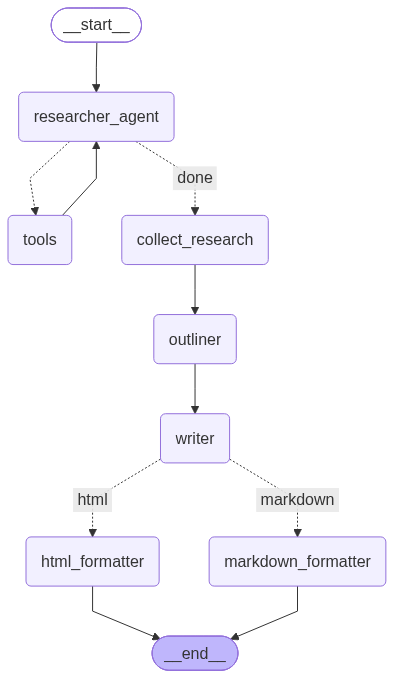

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Image rendering failed, showing text diagram instead:", e)
    print(graph.get_graph().draw_mermaid())

---
# Step 10: Run the pipeline

**What it does:** `graph.invoke(...)` runs the whole graph and returns the **final State**, so `topic`, `research`, `outline`, `article`, and `final_output` are all available afterwards.

**Input:** `topic`, `output_format`, and a starting `messages` list holding the research task. The helper below hides that detail.

**`recursion_limit=25`:** LangGraph stops any graph after a set number of steps and raises `GraphRecursionError`. It is the last-resort backstop against an infinite loop.

**Three safety layers now exist:**
1. the **prompt** asks the model to be economical (soft),
2. the **tool budget** in code forces the loop to end (hard),
3. the **recursion limit** stops anything that slips past both (backstop).

In [15]:
from IPython.display import Markdown, HTML, display

def generate_newsletter(topic: str, output_format: str = "markdown", show: bool = True):
    """Run the full pipeline and (optionally) display the result."""
    result = graph.invoke(
        {"topic": topic, "output_format": output_format, "messages": [make_task(topic)]},
        config={"recursion_limit": 25},
    )
    if show:
        if output_format.strip().lower() == "html":
            display(HTML(result["final_output"]))
        else:
            display(Markdown(result["final_output"]))
    return result


result = generate_newsletter("Latest developments in solid-state batteries", "markdown")

--- Researcher agent thinking (tool calls used: 0/4) ---
    decision: call get_current_date({})
    [tool] get_current_date
--- Researcher agent thinking (tool calls used: 1/4) ---
    decision: call web_search({'query': 'latest developments in solid-state batteries 2026'})
    [tool] web_search: latest developments in solid-state batteries 2026
--- Researcher agent thinking (tool calls used: 2/4) ---
    decision: finished researching
--- Collect research node running ---
--- Outliner node running ---
--- Writer node running ---
--- Markdown formatter running ---


# The Future is Solid: Latest Developments in Solid-State Batteries

## Introduction
Solid-state batteries are on the brink of revolutionizing the energy storage landscape. As of October 2026, advancements in this technology promise enhanced safety, efficiency, and application potential. This transformation is not just theoretical; it is backed by tangible progress and collaborative efforts across the globe.

## 1. Collaborative Development
The advancement of solid-state batteries is a global effort involving a diverse range of stakeholders, including:
- Research institutes
- Material suppliers
- Battery manufacturers
- Automotive original equipment manufacturers (OEMs)
- Investors

Each region contributes uniquely to this landscape, influencing technological priorities and market readiness. This collaborative environment is key to overcoming challenges and accelerating the pace of innovation in solid-state technology.

## 2. Technological Evolution
In 2026, solid-state batteries are rapidly evolving from semi-solid designs to all-solid technologies. This transition is significant, as it opens up new possibilities for performance and application. Alongside this evolution, ongoing discussions about the costs and risks associated with all-solid technologies are shaping investment strategies and future developments in the field.

## 3. Milestones and Scaling
The rollout of MG4 semi-solid electric vehicles (EVs) marks a pivotal milestone in the solid-state battery sector. Additionally, companies like Mercedes and Toyota are actively road-testing new solid-state designs, focusing on:
- Improving energy density
- Enhancing overall performance

These developments signal a growing commitment to integrating solid-state technology into mainstream EV offerings.

## 4. Engineering Challenges and Commercialization
While solid-state batteries are celebrated for their safety features and rapid charging potential, significant engineering challenges remain. Addressing these hurdles is essential to enable widespread commercialization. The industry's ability to navigate these challenges will determine how quickly solid-state batteries can transform the energy storage and electric vehicle markets.

## Conclusion
With significant milestones and ongoing collaborations, solid-state batteries are poised to transform the energy storage and electric vehicle industries. However, addressing engineering challenges will be key to unlocking their full potential in the market.

## Sources
- [IDTechEx](https://www.idtechex.com/en/research-report/solid-state-batteries/1130)
- [Bonnen Batteries](https://www.bonnenbatteries.com/solid-state-batteries-advances-challenges-future-use-cases/)
- [Intelligent Living](https://www.intelligentliving.co/solid-state-battery-scoreboard-2025-2026/)
- [EV Insight Daily](https://evinsightdaily.com/solid-state-batteries-2026/)

### See how the agent behaved

`inspect_searches` summarizes which tools the model chose and in how many passes. Use it to compare topics:

| Topic type | Expected behavior |
|---|---|
| recent news ("latest", "this year") | `get_current_date` first, then `web_search` |
| history or definitions | mostly `wikipedia_lookup` |
| simple, well-known | few or no tool calls |

This is what separates the agent from a fixed researcher that always runs the same searches.

In [16]:
from collections import Counter

def inspect_searches(result):
    msgs = result["messages"]
    passes = [m for m in msgs if isinstance(m, AIMessage) and m.tool_calls]
    calls = [c for m in passes for c in m.tool_calls]

    print(f"Agent turns that requested tools: {len(passes)}")
    print(f"Total tool calls: {len(calls)}  ->  {dict(Counter(c['name'] for c in calls))}\n")
    for i, m in enumerate(passes, 1):
        print(f"Pass {i}:")
        for c in m.tool_calls:
            print(f"   {c['name']}({c['args']})")

inspect_searches(result)

Agent turns that requested tools: 2
Total tool calls: 2  ->  {'get_current_date': 1, 'web_search': 1}

Pass 1:
   get_current_date({})
Pass 2:
   web_search({'query': 'latest developments in solid-state batteries 2026'})


### Verify the routing with a trace

`stream_mode="updates"` yields one entry per node that actually ran, so a branch that was skipped never appears. That is stronger evidence than judging by the output text. Run it once per format and confirm that **only one formatter** shows up each time.

In [17]:
def run_and_trace(topic: str, output_format: str):
    """Run the graph and return (final_output, ordered list of nodes that ran)."""
    inputs = {"topic": topic, "output_format": output_format, "messages": [make_task(topic)]}
    nodes_run, final_output = [], ""
    for step in graph.stream(inputs, stream_mode="updates"):
        for node_name, update in step.items():
            nodes_run.append(node_name)
            final_output = update.get("final_output", final_output)
    return final_output, nodes_run


for fmt in ["markdown", "html"]:
    out, nodes = run_and_trace("Remote work trends this year", fmt)
    print(f"\n[{fmt}] nodes that ran: {' -> '.join(nodes)}")
    print(f"[{fmt}] markdown_formatter ran:", "markdown_formatter" in nodes)
    print(f"[{fmt}] html_formatter ran:    ", "html_formatter" in nodes)

--- Researcher agent thinking (tool calls used: 0/4) ---
    decision: call get_current_date({})
    [tool] get_current_date
--- Researcher agent thinking (tool calls used: 1/4) ---
    decision: call web_search({'query': 'remote work trends 2026'})
    [tool] web_search: remote work trends 2026
--- Researcher agent thinking (tool calls used: 2/4) ---
    decision: finished researching
--- Collect research node running ---
--- Outliner node running ---
--- Writer node running ---
--- Markdown formatter running ---

[markdown] nodes that ran: researcher_agent -> tools -> researcher_agent -> tools -> researcher_agent -> collect_research -> outliner -> writer -> markdown_formatter
[markdown] markdown_formatter ran: True
[markdown] html_formatter ran:     False
--- Researcher agent thinking (tool calls used: 0/4) ---
    decision: call get_current_date({})
    [tool] get_current_date
--- Researcher agent thinking (tool calls used: 1/4) ---
    decision: call web_search({'query': 'remote wo

### Quality checks on the output

Two cheap automated checks catch the most common failures:
1. **Does the HTML output look like HTML**, with real `<a href>` links and no leftover Markdown links?
2. **Were the cited URLs actually in the research?** A URL that is not in the research was invented or altered by the model.

In [18]:
import re

html_result = generate_newsletter("Remote work trends this year", "html", show=False)
raw = html_result["final_output"]
print("Starts with doctype:      ", raw.lstrip().lower().startswith("<!doctype html"))
print("Anchor tags found:        ", raw.count("<a href"))
print("Markdown-style links left:", raw.count("]("))

# Grounding check: every cited URL should appear in the research text
cited = set(re.findall(r"https?://[^\s)\]>\"']+", raw))
for url in sorted(cited):
    status = "OK " if url.rstrip(".,") in html_result["research"] else "NOT IN RESEARCH"
    print(f"[{status}] {url}")

--- Researcher agent thinking (tool calls used: 0/4) ---
    decision: call get_current_date({})
    [tool] get_current_date
--- Researcher agent thinking (tool calls used: 1/4) ---
    decision: call web_search({'query': 'remote work trends 2026'})
    [tool] web_search: remote work trends 2026
--- Researcher agent thinking (tool calls used: 2/4) ---
    decision: finished researching
--- Collect research node running ---
--- Outliner node running ---
--- Writer node running ---
--- HTML formatter running ---
Starts with doctype:       True
Anchor tags found:         4
Markdown-style links left: 0
[OK ] https://www.graygroupintl.com/blog/remote-work-trends-2026/
[NOT IN RESEARCH] https://www.graygroupintl.com/blog/remote-work-trends-2026/</a
[OK ] https://www.roberthalf.com/us/en/insights/research/remote-work-statistics-and-trends
[NOT IN RESEARCH] https://www.roberthalf.com/us/en/insights/research/remote-work-statistics-and-trends</a
[OK ] https://www.splashtop.com/blog/remote-work-t

### Save the output to a file

In [19]:
from google.colab import files

def save_newsletter(result, output_format="markdown", name="newsletter"):
    ext = "html" if output_format.strip().lower() == "html" else "md"
    path = f"{name}.{ext}"
    with open(path, "w", encoding="utf-8") as f:
        f.write(result["final_output"])
    files.download(path)

# save_newsletter(html_result, "html", "sample_newsletter")

---
# Lessons learned and known limitations

## Problems found while building, and how each was fixed

| Problem | Cause | Fix |
|---|---|---|
| Agent searched for "2023" and cited three-year-old sources | The model assumed the current year from training data | Added `get_current_date` and a prompt rule to call it **first** |
| Model lost context during the loop | Plain fields overwrite | `messages` uses the `add_messages` reducer |
| Tool budget shown as 5/2 | The model can request several tools in one turn, and the check runs per turn | Documented; treat it as a per-turn budget |
| A rebuilt node had no effect | A compiled graph keeps the function it was given | Wrapped graph creation in `build_graph()` and rebuild after edits |
| Search sometimes returned "No results" | Free search endpoint rate-limits | Added retries and a text fallback so the pipeline never crashes |
| Unsure whether HTML was really HTML | A model can ignore format instructions silently | Added an `<html` check and link-count checks |

## Limitations

- Research uses search **snippets**, not full pages, so depth is limited.
- DuckDuckGo results vary between runs, so the same topic can give different articles.
- The date comes from the Colab server clock (UTC).
- Tool choice is probabilistic. Run the same topic several times to see variation.
- The model can still misread a snippet. The URL check confirms a link exists in the research, not that the claim is correct.

## Ideas for next steps

1. **Reviewer node:** critique the article against the research, then revise it.
2. **Review loop:** send the article back to the writer until it passes, with a maximum number of revisions.
3. **Human-in-the-loop:** pause after the outline for approval (needs a checkpointer).
4. **Structured output:** have the reviewer return a Pydantic object (score, issues) so routing is reliable.
5. **Retries per node:** use LangGraph's `RetryPolicy` for flaky tools.
6. **Tracing:** enable LangSmith to inspect every prompt and tool call.